# Massive Transfusion Prediction -- Logistic Regression Workflow

**Task:** Binary classification -- predict whether a trauma patient requires Massive Transfusion (MT = 1)
**Dataset:** CRASH2_Final_1000.xlsx -- 1 000 patients, 25 % MT prevalence
**Scope (this notebook):** EDA · preprocessing · GCS experiment · feature diagnostics · baseline LR · hyperparameter search (L1/L2/ElasticNet) · OOF threshold selection · single held-out test evaluation · coefficient & permutation-importance analysis · artifact saving.

> Teammates will implement Random Forest and XGBoost separately.
> A placeholder comparison table is written to `outputs/logistic_regression/final_report.txt`.
> **Run from the project root directory** so that relative paths resolve correctly.

## Imports

In [1]:
import json
import warnings
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.exceptions import ConvergenceWarning
from sklearn.inspection import permutation_importance as sk_perm_importance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    average_precision_score, brier_score_loss, classification_report,
    confusion_matrix, precision_recall_curve, roc_auc_score, roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold,
    cross_val_predict, cross_val_score, train_test_split,
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print('Imports OK')

Imports OK


## Configuration

In [2]:
RANDOM_SEED     = 42
TEST_SIZE       = 0.20
MIN_SPECIFICITY = 0.75

DATA_PATH    = Path('data/CRASH2_Final_1000.xlsx')
TARGET       = 'MT'
OUTPUT_BASE  = Path('outputs/logistic_regression')
FIGURES_DIR  = OUTPUT_BASE / 'figures'

# Columns removed before any analysis
DROP_ALWAYS = ['Patient_ID', 'Units_Transfused', 'Time_to_Hospital_min']

CATEGORICAL_COLS = {
    'Sex':         {'Female': 1, 'Male': 0},
    'Injury_Type': {'Penetrating': 1, 'Blunt': 0},
}

# Physiological survivable bounds -- clinical constants, not data-derived
CLIP_BOUNDS = {
    'Systolic_BP_mmHg': (40, 250),
    'Heart_Rate_BPM':   (20, 220),
}

# Single feature set used throughout all modeling steps.
# Shock_Index (= HR / SBP) is treated as a regular clinical feature --
# regularization and cross-validation determine its contribution.
BASE_FEATURES = [
    'Systolic_BP_mmHg', 'Heart_Rate_BPM', 'Age',
    'Respiratory_Rate_BPM', 'Lactate_mmol_L', 'Arterial_Base_Excess',
    'Injury_Type_Coded', 'Sex_Coded', 'Shock_Index',
]

CORR_FLAG = 0.70  # |r| flagged in EDA interpretation

CONTINUOUS_COLS = [
    'Age', 'Systolic_BP_mmHg', 'Heart_Rate_BPM',
    'Respiratory_Rate_BPM', 'Lactate_mmol_L', 'Arterial_Base_Excess',
    'Shock_Index',
]

# Create output directories now so later cells can save directly
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_SEED)
print('Configuration OK -- output dirs created')

Configuration OK -- output dirs created


---
## 1. Data Loading

In [3]:
def load_data(path):
    df = pd.read_excel(path)
    print(f'Path    : {path}')
    print(f'Shape   : {df.shape}')
    print(f'Columns : {df.columns.tolist()}')
    print(f'\nDtypes:\n{df.dtypes.to_string()}')
    print(f'\nDuplicates: {df.duplicated().sum()}')
    id_col = df.columns[0]
    print(f'Unique {id_col}: {df[id_col].nunique()}')
    return df

In [5]:
df = load_data("../data/CRASH2_Final_1000.xlsx")
df.head()

Path    : ../data/CRASH2_Final_1000.xlsx
Shape   : (1000, 14)
Columns : ['Patient_ID', 'Age', 'Sex', 'Systolic_BP_mmHg', 'Heart_Rate_BPM', 'Respiratory_Rate_BPM', 'GCS_Score', 'Injury_Type', 'Units_Transfused', 'Lactate_mmol_L', 'Arterial_Base_Excess', 'Time_to_Hospital_min', 'Shock_Index', 'MT']

Dtypes:
Patient_ID               object
Age                       int64
Sex                      object
Systolic_BP_mmHg          int64
Heart_Rate_BPM            int64
Respiratory_Rate_BPM      int64
GCS_Score                 int64
Injury_Type              object
Units_Transfused          int64
Lactate_mmol_L          float64
Arterial_Base_Excess    float64
Time_to_Hospital_min      int64
Shock_Index             float64
MT                        int64

Duplicates: 0
Unique Patient_ID: 1000


,Patient_ID,Age,Sex,Systolic_BP_mmHg,Heart_Rate_BPM,Respiratory_Rate_BPM,GCS_Score,Injury_Type,Units_Transfused,Lactate_mmol_L,Arterial_Base_Excess,Time_to_Hospital_min,Shock_Index,MT
0,CRASH2-17194,74,Female,66,116,37,10,Blunt,12,4.3,-10.6,72,1.76,1
1,CRASH2-02435,74,Male,99,94,25,6,Penetrating,0,4.0,-2.6,68,0.95,0
2,CRASH2-09404,73,Male,162,148,39,10,Penetrating,0,2.8,-3.7,64,0.91,0
3,CRASH2-16873,41,Male,140,130,34,10,Blunt,10,2.0,-13.9,69,0.93,1
4,CRASH2-18169,28,Male,79,89,15,12,Penetrating,9,8.2,-1.4,74,1.13,1


---
## 2. Early Column Removal and Categorical Encoding

Three columns are removed **before any EDA**:

| Column | Reason |
|---|---|
| `Patient_ID` | Row identifier -- no predictive value |
| `Units_Transfused` | Directly defines the MT label -- **data leakage** |
| `Time_to_Hospital_min` | Excluded by project scope decision |

Categorical encoding is deterministic (no statistics learned from data).

In [6]:
def drop_early_columns(df, cols):
    reasons = {
        'Patient_ID':           'row identifier -- no predictive value',
        'Units_Transfused':     'directly defines the MT label -- data leakage',
        'Time_to_Hospital_min': 'excluded by project scope decision',
    }
    to_drop = [c for c in cols if c in df.columns]
    for c in to_drop:
        print(f"  Dropping '{c}': {reasons.get(c, 'scheduled for removal')}")
    return df.drop(columns=to_drop)


def encode_categoricals(df):
    for col, mapping in CATEGORICAL_COLS.items():
        if col not in df.columns:
            continue
        new_col = col + '_Coded'
        df[new_col] = df[col].map(mapping)
        df = df.drop(columns=[col])
        print(f"  '{col}' -> '{new_col}'  {mapping}")
    return df

In [7]:
df = drop_early_columns(df, DROP_ALWAYS)
df = encode_categoricals(df)

# Compute Shock_Index on the full dataframe so EDA includes it.
# After the train/test split it will be recomputed from clipped vitals.
if 'Systolic_BP_mmHg' in df.columns and 'Heart_Rate_BPM' in df.columns:
    df['Shock_Index'] = df['Heart_Rate_BPM'] / df['Systolic_BP_mmHg']
    print("  'Shock_Index' computed (HR / SBP)")

print(f'\nRemaining columns ({len(df.columns)}):')
print(df.columns.tolist())
print(f'Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

  Dropping 'Patient_ID': row identifier -- no predictive value
  Dropping 'Units_Transfused': directly defines the MT label -- data leakage
  Dropping 'Time_to_Hospital_min': excluded by project scope decision
  'Sex' -> 'Sex_Coded'  {'Female': 1, 'Male': 0}
  'Injury_Type' -> 'Injury_Type_Coded'  {'Penetrating': 1, 'Blunt': 0}
  'Shock_Index' computed (HR / SBP)

Remaining columns (11):
['Age', 'Systolic_BP_mmHg', 'Heart_Rate_BPM', 'Respiratory_Rate_BPM', 'GCS_Score', 'Lactate_mmol_L', 'Arterial_Base_Excess', 'Shock_Index', 'MT', 'Sex_Coded', 'Injury_Type_Coded']
Missing values:
Series([], dtype: int64)


---
## 3. Exploratory Data Analysis

All EDA runs on the cleaned dataframe.
`Time_to_Hospital_min`, `Patient_ID`, and `Units_Transfused` are already removed.
`Shock_Index` is included as a regular feature and appears in all EDA plots.
Figures are saved to `outputs/logistic_regression/figures/` and displayed inline.

### 3.1 Class Distribution

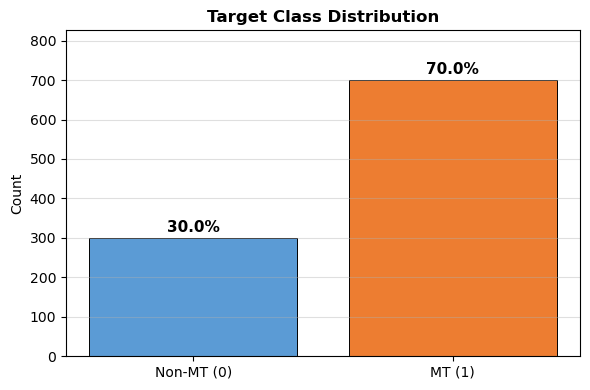

Non-MT: 300 (30.0%)
MT    : 700 (70.0%)
Imbalance ratio: 0.4:1
=> accuracy alone is misleading; Recall and PR-AUC are primary metrics
=> class_weight="balanced" is applied in all LR configurations


In [8]:
def plot_class_distribution(df, target, out_dir):
    counts = df[target].value_counts().sort_index()
    pcts   = df[target].value_counts(normalize=True).sort_index() * 100
    labels = ['Non-MT (0)', 'MT (1)']
    colors = ['#5B9BD5', '#ED7D31']

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(labels, counts.values, color=colors,
                  edgecolor='black', linewidth=0.7)
    for bar, pct in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 8,
                f'{pct:.1f}%', ha='center', va='bottom',
                fontsize=11, fontweight='bold')
    ax.set_title('Target Class Distribution', fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts.values) * 1.18)
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.savefig(out_dir / 'figures/01_class_distribution.png', dpi=150)
    plt.show()

    print(f'Non-MT: {counts.get(0,0)} ({pcts.get(0,0):.1f}%)')
    print(f'MT    : {counts.get(1,0)} ({pcts.get(1,0):.1f}%)')
    ratio = counts.get(0,0) / max(counts.get(1,1), 1)
    print(f'Imbalance ratio: {ratio:.1f}:1')
    print('=> accuracy alone is misleading; Recall and PR-AUC are primary metrics')
    print('=> class_weight="balanced" is applied in all LR configurations')

plot_class_distribution(df, TARGET, OUTPUT_BASE)

### 3.2 Missing Values

In [9]:
def plot_missing_values(df, out_dir):
    miss = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    miss = miss[miss > 0]

    if miss.empty:
        print('No missing values detected.')
        return

    colors = [
        '#C00000' if v > 30 else '#ED7D31' if v > 10 else '#5B9BD5'
        for v in miss.values
    ]
    fig, ax = plt.subplots(figsize=(8, max(3, len(miss) * 0.55)))
    ax.barh(miss.index, miss.values, color=colors,
            edgecolor='black', linewidth=0.6)
    ax.axvline(30, color='darkred', ls='--', lw=1.2, label='30% threshold')
    ax.set_xlabel('% Missing')
    ax.set_title('Missing Values by Column', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.4)
    for i, (col, val) in enumerate(miss.items()):
        ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(out_dir / 'figures/02_missing_values.png', dpi=150)
    plt.show()

    for col, val in miss.items():
        print(f'  {col}: {val:.1f}% missing')
    if 'GCS_Score' in miss.index:
        print('  => GCS_Score at 37.9% is the dominant gap.')
        print('     Section 5 tests drop vs median-impute inside the CV pipeline.')

plot_missing_values(df, OUTPUT_BASE)

No missing values detected.


### 3.3 Feature Histograms by MT Class

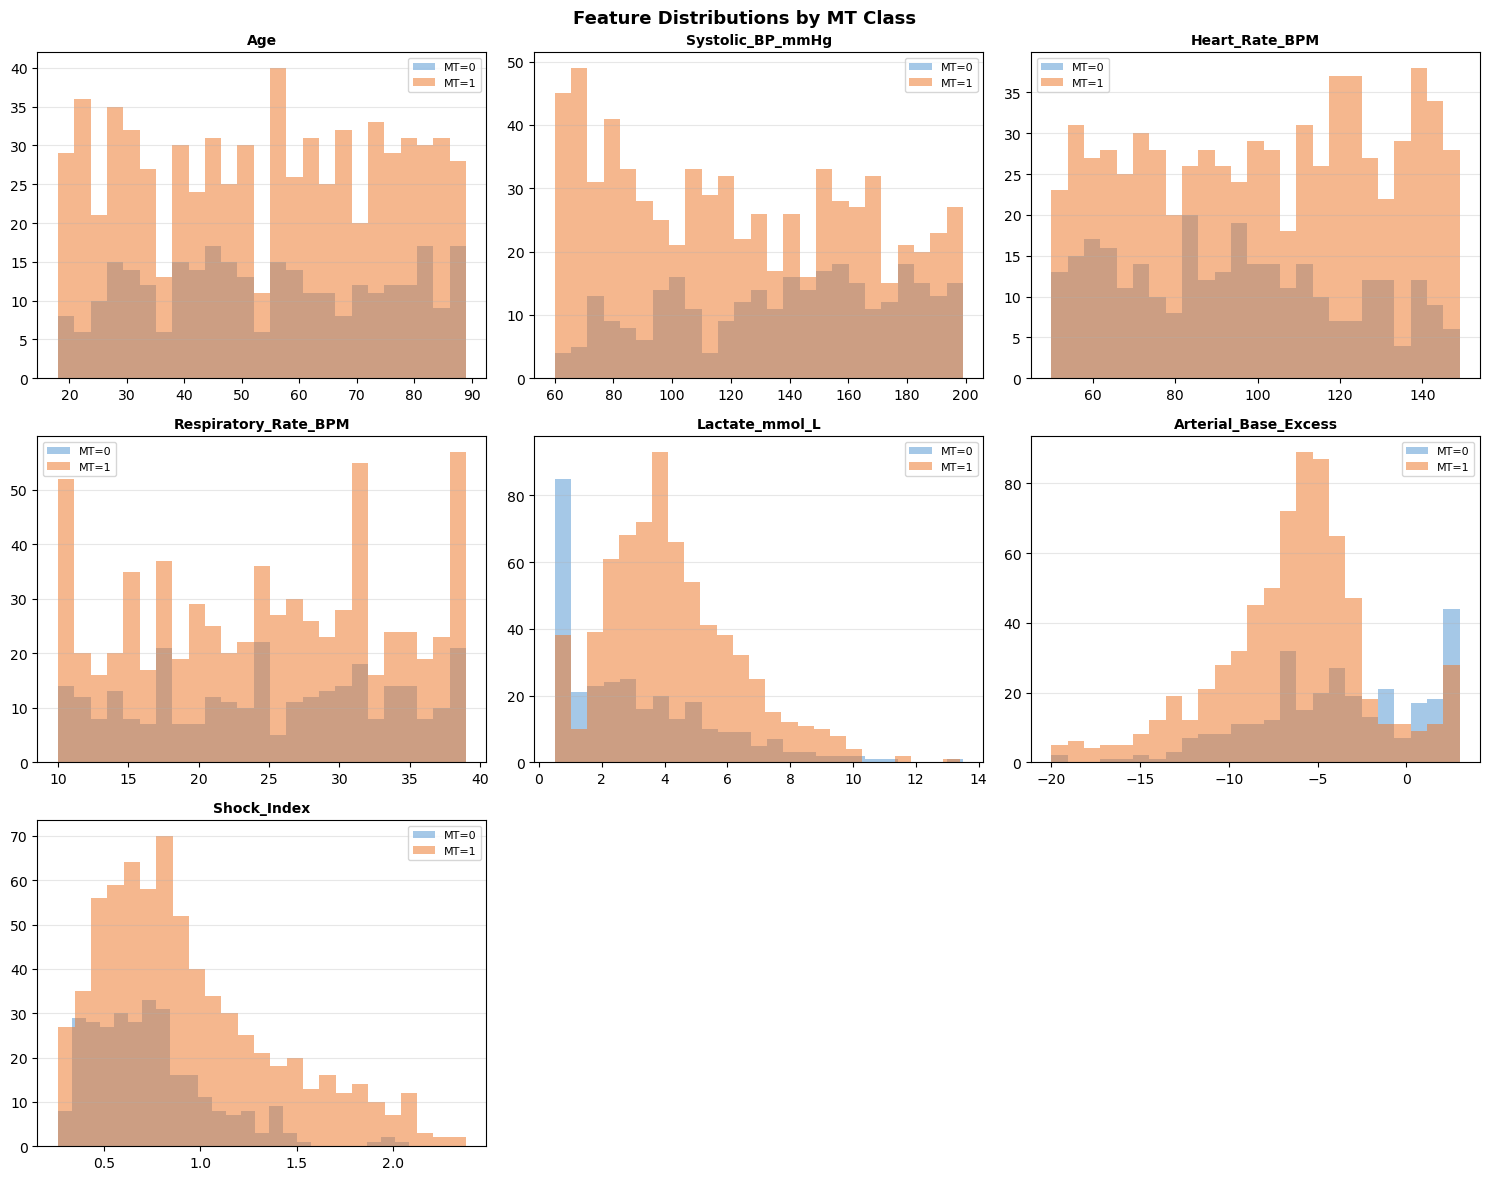

Feature                         Skew   Mean MT=0   Mean MT=1      Diff
  -----------------------------------------------------------------
  Age                          -0.02       54.74       53.78     -0.96
  Systolic_BP_mmHg             +0.05      138.14      122.20    -15.94
  Heart_Rate_BPM               +0.00       94.46      101.30     +6.84
  Respiratory_Rate_BPM         -0.08       25.12       24.86     -0.26
  Lactate_mmol_L               +0.67        3.05        4.22     +1.18
  Arterial_Base_Excess         -0.29       -3.84       -6.37     -2.54
  Shock_Index                  +1.05        0.74        0.94     +0.20


In [10]:
def plot_feature_histograms(df, target, cont_cols, out_dir):
    present = [c for c in cont_cols if c in df.columns]
    if not present:
        print('No continuous columns to plot.')
        return
    ncols = 3
    nrows = int(np.ceil(len(present) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = np.array(axes).flatten()
    palette = {0: '#5B9BD5', 1: '#ED7D31'}
    for i, col in enumerate(present):
        ax = axes[i]
        for cls in [0, 1]:
            vals = df[df[target] == cls][col].dropna()
            ax.hist(vals, bins=25, alpha=0.55, color=palette[cls],
                    label=f'MT={cls}', edgecolor='none')
        ax.set_title(col, fontweight='bold', fontsize=10)
        ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    for j in range(len(present), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle('Feature Distributions by MT Class',
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(out_dir / 'figures/03_feature_histograms.png', dpi=150)
    plt.show()

    print(f'{"Feature":<28} {"Skew":>7}  {"Mean MT=0":>10}  {"Mean MT=1":>10}  {"Diff":>8}')
    print('  ' + '-'*65)
    for col in present:
        skew = df[col].skew()
        m0   = df[df[target]==0][col].mean()
        m1   = df[df[target]==1][col].mean()
        print(f'  {col:<26} {skew:>+7.2f}  {m0:>10.2f}  {m1:>10.2f}  {m1-m0:>+8.2f}')

cont_cols = [c for c in CONTINUOUS_COLS if c in df.columns]
plot_feature_histograms(df, TARGET, cont_cols, OUTPUT_BASE)

### 3.4 Violin Plots by MT Class

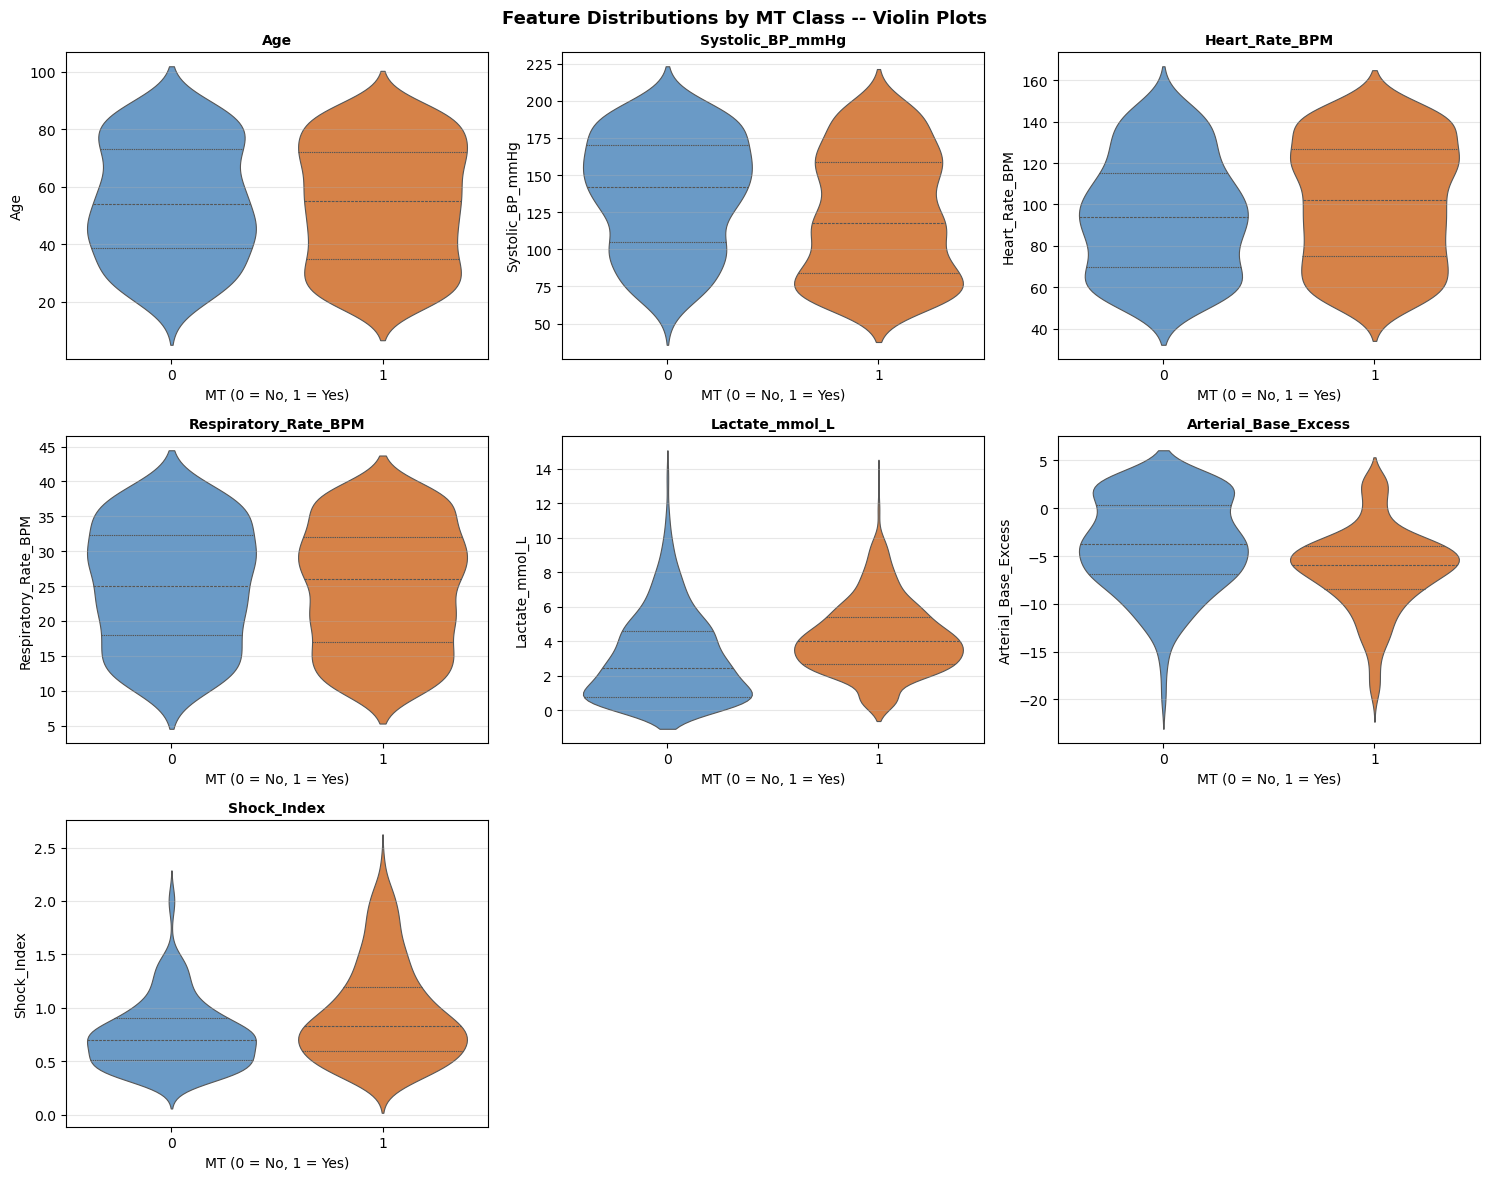

Wide separation between MT=0 and MT=1 bodies => strong univariate signal.


In [11]:
def plot_violin_by_target(df, target, cont_cols, out_dir):
    present = [c for c in cont_cols if c in df.columns]
    if not present:
        return
    ncols = 3
    nrows = int(np.ceil(len(present) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = np.array(axes).flatten()
    palette = ['#5B9BD5', '#ED7D31']   # ordered by sorted categories: 0, 1
    for i, col in enumerate(present):
        ax = axes[i]
        plot_df = df[[target, col]].dropna()
        sns.violinplot(data=plot_df, x=target, y=col,
                       hue=target, palette=palette,
                       inner='quart', ax=ax, linewidth=0.8,
                       legend=False)
        ax.set_title(col, fontweight='bold', fontsize=10)
        ax.set_xlabel('MT (0 = No, 1 = Yes)')
        ax.grid(axis='y', alpha=0.3)
    for j in range(len(present), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle('Feature Distributions by MT Class -- Violin Plots',
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(out_dir / 'figures/04_violin_by_target.png', dpi=150)
    plt.show()
    print('Wide separation between MT=0 and MT=1 bodies => strong univariate signal.')

plot_violin_by_target(df, TARGET, cont_cols, OUTPUT_BASE)

### 3.5 Correlation Heatmap

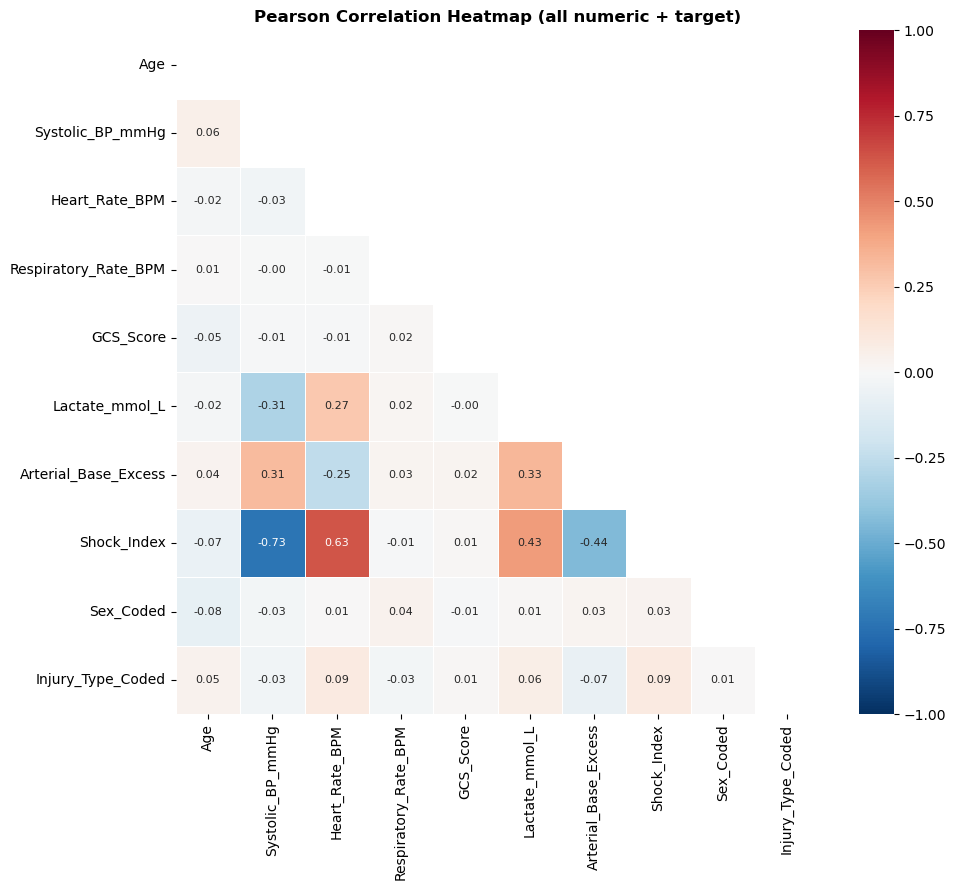

Pairs with |r| >= 0.7 (descriptive only -- no features removed):
  Systolic_BP_mmHg  <->  Shock_Index:  r = -0.732

  Note: Shock_Index = HR / SBP, so high correlations with
  those raw vitals are algebraically expected.
  Shock_Index is excluded from all LR model fitting.


In [12]:
def plot_correlation_heatmap(df, target, out_dir):
    all_numeric = [c for c in df.columns
                   if c != target and pd.api.types.is_numeric_dtype(df[c])]
    corr = df[all_numeric].corr(method='pearson')
    mask = np.triu(np.ones_like(corr, dtype=bool))
    size = max(8, len(all_numeric))
    fig, ax = plt.subplots(figsize=(size, size-1))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                linewidths=0.5, ax=ax, annot_kws={'size': 8})
    ax.set_title('Pearson Correlation Heatmap (all numeric + target)',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(out_dir / 'figures/05_correlation_heatmap.png', dpi=150)
    plt.show()

    print(f'Pairs with |r| >= {CORR_FLAG} (descriptive only -- no features removed):')
    cols = corr.columns.tolist()
    flagged = []
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = corr.iloc[i, j]
            if abs(r) >= CORR_FLAG:
                flagged.append((cols[i], cols[j], r))
    if flagged:
        for a, b, r in sorted(flagged, key=lambda x: -abs(x[2])):
            print(f'  {a}  <->  {b}:  r = {r:+.3f}')
        print('\n  Note: Shock_Index = HR / SBP, so high correlations with')
        print('  those raw vitals are algebraically expected.')
        print('  Shock_Index is excluded from all LR model fitting.')
    else:
        print(f'  No pairs exceed |r| = {CORR_FLAG}.')

plot_correlation_heatmap(df, TARGET, OUTPUT_BASE)

---
## 4. Train / Test Split and Preprocessing

**Order matters:**
1. Split first -- imputers and scalers are never fitted on the test set.
2. Apply physiological clipping (clinical constants -- not data-derived, not leakage).
3. Recompute `Shock_Index` from clipped HR and SBP so the model sees consistent values.

In [13]:
def stratified_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state,
    )
    print(f'Train: {X_train.shape}  MT rate: {y_train.mean():.1%}')
    print(f'Test : {X_test.shape}   MT rate: {y_test.mean():.1%}')
    return X_train, X_test, y_train, y_test


def apply_clinical_clipping(X_train, X_test, bounds):
    """
    Bounds are physiological constants (not derived from training data),
    so applying them to both sets is NOT leakage.
    """
    for col, (lo, hi) in bounds.items():
        if col not in X_train.columns:
            continue
        n_tr = ((X_train[col] < lo) | (X_train[col] > hi)).sum()
        n_te = ((X_test[col]  < lo) | (X_test[col]  > hi)).sum()
        X_train[col] = X_train[col].clip(lo, hi)
        X_test[col]  = X_test[col].clip(lo, hi)
        print(f"  '{col}' clipped to [{lo}, {hi}]: "
              f"{n_tr} train rows, {n_te} test rows")
    return X_train, X_test


def recalculate_shock_index(X):
    """Recompute Shock_Index = HR / SBP from (clipped) vitals."""
    if 'Systolic_BP_mmHg' in X.columns and 'Heart_Rate_BPM' in X.columns:
        X = X.copy()
        X['Shock_Index'] = X['Heart_Rate_BPM'] / X['Systolic_BP_mmHg']
    return X


def build_lr_pipeline():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('lr',      LogisticRegression(max_iter=5000, random_state=RANDOM_SEED)),
    ])

In [14]:
y = df[TARGET]
X = df.drop(columns=[TARGET])

X_train, X_test, y_train, y_test = stratified_split(X, y)

print('\nApplying clinical clipping ...')
X_train, X_test = apply_clinical_clipping(X_train, X_test, CLIP_BOUNDS)

# Recompute Shock_Index from clipped HR and SBP
X_train = recalculate_shock_index(X_train)
X_test  = recalculate_shock_index(X_test)

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

FEATURES = [f for f in BASE_FEATURES if f in X_train.columns]
print(f'\nStratifiedKFold(n_splits=5) created.')
print(f'Feature set ({len(FEATURES)} features): {FEATURES}')

Train: (800, 10)  MT rate: 70.0%
Test : (200, 10)   MT rate: 70.0%

Applying clinical clipping ...
  'Systolic_BP_mmHg' clipped to [40, 250]: 0 train rows, 0 test rows
  'Heart_Rate_BPM' clipped to [20, 220]: 0 train rows, 0 test rows

StratifiedKFold(n_splits=5) created.
Feature set (9 features): ['Systolic_BP_mmHg', 'Heart_Rate_BPM', 'Age', 'Respiratory_Rate_BPM', 'Lactate_mmol_L', 'Arterial_Base_Excess', 'Injury_Type_Coded', 'Sex_Coded', 'Shock_Index']


---
## 7. Metrics Helpers

Core metric functions used throughout the notebook.
Logic reused from `MT_ML.ipynb` cells 16 -- re-implemented here as named functions.

| Function | Purpose |
|---|---|
| `compute_metrics` | Full metric suite: Recall, Spec, Prec, F1, F2, ROC-AUC, PR-AUC, Brier |
| `select_threshold_f2` | OOF sweep → threshold maximising F2 |
| `select_threshold_spec` | OOF sweep → max Recall subject to Spec ≥ 0.75 |

In [15]:
def compute_metrics(y_true, probs, threshold, label=''):
    preds          = (probs >= threshold).astype(int)
    cm             = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel()
    recall  = tp / (tp+fn)          if (tp+fn)>0          else 0.
    spec    = tn / (tn+fp)          if (tn+fp)>0          else 0.
    prec    = tp / (tp+fp)          if (tp+fp)>0          else 0.
    f1      = 2*prec*recall/(prec+recall)   if (prec+recall)>0  else 0.
    f2      = (5*prec*recall)/(4*prec+recall) if (4*prec+recall)>0 else 0.
    bal_acc = (recall + spec) / 2
    pr_auc  = average_precision_score(y_true, probs)
    roc_auc = roc_auc_score(y_true, probs)
    brier   = brier_score_loss(y_true, probs)
    return {
        'Model': label, 'Threshold': round(threshold,4),
        'PR-AUC': round(pr_auc,3), 'ROC-AUC': round(roc_auc,3),
        'Recall': round(recall,3), 'Specificity': round(spec,3),
        'Precision': round(prec,3), 'F1': round(f1,3), 'F2': round(f2,3),
        'Bal-Accuracy': round(bal_acc,3), 'Brier': round(brier,3),
    }, cm


def select_threshold_f2(oof_probs, y_true):
    best_f2, best_t = 0., 0.5
    for t in np.linspace(0.05, 0.95, 500):
        preds          = (oof_probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        prec = tp/(tp+fp) if (tp+fp)>0 else 0.
        rec  = tp/(tp+fn) if (tp+fn)>0 else 0.
        f2   = (5*prec*rec)/(4*prec+rec) if (4*prec+rec)>0 else 0.
        if f2 > best_f2:
            best_f2, best_t = f2, t
    print(f'  [F2 threshold]       t = {best_t:.3f}   OOF F2 = {best_f2:.3f}')
    return float(best_t)


def select_threshold_spec(oof_probs, y_true, min_spec=MIN_SPECIFICITY):
    best_rec, best_t = 0., None
    for t in np.linspace(0.05, 0.95, 500):
        preds          = (oof_probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        spec = tn/(tn+fp) if (tn+fp)>0 else 0.
        rec  = tp/(tp+fn) if (tp+fn)>0 else 0.
        if spec >= min_spec and rec > best_rec:
            best_rec, best_t = rec, t
    if best_t is None:
        print(f'  [Spec>={min_spec}] no threshold satisfies this constraint')
    else:
        print(f'  [Spec>={min_spec}] t = {best_t:.3f}   OOF Recall = {best_rec:.3f}')
    return float(best_t) if best_t is not None else None

print('Metrics helpers defined.')

Metrics helpers defined.


---
## 8. Baseline Logistic Regression

Default configuration: C=1, L2, lbfgs, `class_weight='balanced'`.
Evaluated via **OOF predictions on training data only** -- `X_test` is not used here.
Provides a reference point for measuring the gain from hyperparameter tuning.

In [16]:
def build_baseline_lr(features, X_train, y_train, skf):
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('lr',      LogisticRegression(
            C=1, penalty='l2', solver='lbfgs',
            class_weight='balanced',
            max_iter=5000, random_state=RANDOM_SEED,
        )),
    ])
    cv_scores = cross_val_score(
        pipe, X_train[features], y_train,
        cv=skf, scoring='average_precision', n_jobs=-1,
    )
    print(f'CV PR-AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

    oof = cross_val_predict(
        pipe, X_train[features], y_train,
        cv=skf, method='predict_proba',
    )[:, 1]
    thr_f2   = select_threshold_f2(oof, y_train)
    thr_spec = select_threshold_spec(oof, y_train)

    m_f2, _ = compute_metrics(y_train, oof, thr_f2, 'Baseline OOF (F2-thr)')
    print('\nOOF metrics at F2-threshold (training data only):')
    for k, v in m_f2.items():
        if k != 'Model':
            print(f'  {k:<15}: {v}')
    return {'cv_prauc': float(cv_scores.mean()),
            'thr_f2': thr_f2, 'thr_spec': thr_spec,
            'oof_metrics_f2': m_f2}

In [17]:
print('=== Baseline Logistic Regression ===')
baseline = build_baseline_lr(FEATURES, X_train, y_train, SKF)

=== Baseline Logistic Regression ===
CV PR-AUC: 0.9057 +/- 0.0148
  [F2 threshold]       t = 0.111   OOF F2 = 0.922
  [Spec>=0.75] t = 0.472   OOF Recall = 0.723

OOF metrics at F2-threshold (training data only):
  Threshold      : 0.1113
  PR-AUC         : 0.902
  ROC-AUC        : 0.804
  Recall         : 1.0
  Specificity    : 0.017
  Precision      : 0.704
  F1             : 0.826
  F2             : 0.922
  Bal-Accuracy   : 0.508
  Brier          : 0.183


---
## 9. Hyperparameter Search

Three **separate** grids avoid invalid solver / penalty / l1_ratio combinations:

| Grid | Penalty | Solver | l1_ratio |
|---|---|---|---|
| L1 | l1 | liblinear | -- |
| L2 | l2 | lbfgs | -- |
| ElasticNet | elasticnet | saga | [0.1, 0.3, 0.5, 0.7, 0.9] |

Scoring: `average_precision` (PR-AUC), 5-fold stratified CV.
`ConvergenceWarning`s are captured and reported; they do not halt execution.
The overall best estimator is selected by highest CV PR-AUC across all grids.

In [18]:
def build_param_grids():
    C_range = [0.001, 0.01, 0.1, 1, 10, 100]
    common  = {'lr__class_weight': ['balanced'], 'lr__max_iter': [5000]}
    return [
        ('L1 / liblinear',    {**common,
            'lr__penalty': ['l1'], 'lr__solver': ['liblinear'], 'lr__C': C_range}),
        ('L2 / lbfgs',        {**common,
            'lr__penalty': ['l2'], 'lr__solver': ['lbfgs'],     'lr__C': C_range}),
        ('ElasticNet / saga', {**common,
            'lr__penalty':  ['elasticnet'], 'lr__solver': ['saga'],
            'lr__C':        C_range,
            'lr__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}),
    ]


def run_hyperparameter_search(features, X_train, y_train, skf):
    pipe        = build_lr_pipeline()
    best_score  = -1.
    best_est    = None
    best_params = None

    for name, grid in build_param_grids():
        print(f'\n  -- Grid: {name}')
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always', ConvergenceWarning)
            gs = GridSearchCV(pipe, grid, cv=skf,
                              scoring='average_precision',
                              n_jobs=-1, refit=True)
            gs.fit(X_train[features], y_train)

        n_warn = sum(1 for w in caught
                     if issubclass(w.category, ConvergenceWarning))
        if n_warn:
            print(f'    WARNING: {n_warn} ConvergenceWarning(s). '
                  f'max_iter=5000 may need increasing.')

        print(f'  Best params : {gs.best_params_}')
        print(f'  CV PR-AUC   : {gs.best_score_:.4f}')

        if gs.best_score_ > best_score:
            best_score  = gs.best_score_
            best_est    = gs.best_estimator_
            best_params = gs.best_params_

    print(f'\n=== Overall winner ===')
    print(f'  Params    : {best_params}')
    print(f'  CV PR-AUC : {best_score:.4f}')
    return best_est, best_params, float(best_score)

In [19]:
print('=== Hyperparameter Search ===')
best_pipeline, best_params, best_cv_prauc = run_hyperparameter_search(
    FEATURES, X_train, y_train, SKF,
)

=== Hyperparameter Search ===

  -- Grid: L1 / liblinear
  Best params : {'lr__C': 10, 'lr__class_weight': 'balanced', 'lr__max_iter': 5000, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}
  CV PR-AUC   : 0.9061

  -- Grid: L2 / lbfgs
  Best params : {'lr__C': 100, 'lr__class_weight': 'balanced', 'lr__max_iter': 5000, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
  CV PR-AUC   : 0.9059

  -- Grid: ElasticNet / saga
  Best params : {'lr__C': 10, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.7, 'lr__max_iter': 5000, 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}
  CV PR-AUC   : 0.9061

=== Overall winner ===
  Params    : {'lr__C': 10, 'lr__class_weight': 'balanced', 'lr__max_iter': 5000, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}
  CV PR-AUC : 0.9061


---
## 10. Threshold Selection on OOF Predictions (Training Data Only)

`X_test` is **never** used in this cell.
OOF probabilities come from `cross_val_predict` on the training set.
Two thresholds are selected:

| Threshold | Criterion |
|---|---|
| `thr_f2` | Maximises F2 score on OOF predictions |
| `thr_spec` | Maximises Recall subject to Specificity ≥ 0.75 |

In [20]:
def select_thresholds_on_oof(pipeline, features, X_train, y_train, skf):
    """X_test is never passed to or used by this function."""
    print('Generating OOF probabilities on training data ...')
    oof = cross_val_predict(
        pipeline, X_train[features], y_train,
        cv=skf, method='predict_proba',
    )[:, 1]
    thr_f2   = select_threshold_f2(oof, y_train)
    thr_spec = select_threshold_spec(oof, y_train)
    return thr_f2, thr_spec

In [21]:
thr_f2, thr_spec = select_thresholds_on_oof(
    best_pipeline, FEATURES, X_train, y_train, SKF,
)
print(f'\nThresholds selected:')
print(f'  F2-optimal  : {thr_f2:.4f}')
print(f'  Spec>=0.75  : {thr_spec}')

Generating OOF probabilities on training data ...
  [F2 threshold]       t = 0.102   OOF F2 = 0.922
  [Spec>=0.75] t = 0.467   OOF Recall = 0.725

Thresholds selected:
  F2-optimal  : 0.1023
  Spec>=0.75  : 0.4666332665330661


---
## 11. Final Evaluation on Held-Out Test Set

The best pipeline is fitted on **all** training data, then evaluated **once** on the held-out test set.
No further model adjustments are made after this cell.

Plots saved:
- `06_confusion_matrix_f2.png`
- `07_confusion_matrix_spec.png`
- `08_roc_curve.png`
- `09_pr_curve.png`
- `10_calibration_curve.png`

In [22]:
def plot_confusion_matrix(cm, title, out_dir, filename):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1,
                xticklabels=['Non-MT','MT'], yticklabels=['Non-MT','MT'], ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.savefig(out_dir / f'figures/{filename}', dpi=150)
    plt.show()


def plot_roc(probs, y_test, thr_f2, out_dir):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val     = roc_auc_score(y_test, probs)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color='#2E75B6', lw=2, label=f'LR (AUC={auc_val:.3f})')
    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random')
    tn,fp,fn,tp = confusion_matrix(y_test,(probs>=thr_f2).astype(int)).ravel()
    ax.scatter(fp/max(fp+tn,1), tp/max(tp+fn,1), color='#ED7D31', s=90, zorder=5,
               label=f'F2 thr ({thr_f2:.3f})')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title('ROC Curve -- Logistic Regression (Test Set)', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / 'figures/08_roc_curve.png', dpi=150)
    plt.show()


def plot_pr(probs, y_test, thr_f2, out_dir):
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, probs)
    pr_auc   = average_precision_score(y_test, probs)
    prevalence = float(y_test.mean())
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(rec_arr, prec_arr, color='#2E75B6', lw=2,
            label=f'LR (PR-AUC={pr_auc:.3f})')
    ax.axhline(prevalence, color='grey', ls=':', lw=1.5,
               label=f'No-skill ({prevalence:.2f})')
    tn,fp,fn,tp = confusion_matrix(y_test,(probs>=thr_f2).astype(int)).ravel()
    p_pt = tp/max(tp+fp,1); r_pt = tp/max(tp+fn,1)
    ax.scatter(r_pt, p_pt, color='#ED7D31', s=90, zorder=5,
               label=f'F2 thr ({thr_f2:.3f})')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve -- Logistic Regression (Test Set)',
                 fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / 'figures/09_pr_curve.png', dpi=150)
    plt.show()


def plot_calibration(probs, y_test, brier, out_dir):
    prob_true, prob_pred = calibration_curve(
        y_test, probs, n_bins=8, strategy='quantile')
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(prob_pred, prob_true, 'o-', color='#2E75B6', lw=2,
            label='LR calibration')
    ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Perfect calibration')
    ax.set_title(f'Calibration Curve -- LR  |  Brier = {brier:.3f}',
                 fontweight='bold')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Observed MT fraction')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / 'figures/10_calibration_curve.png', dpi=150)
    plt.show()

Results at F2-threshold (0.1023):
  Threshold      : 0.1023
  PR-AUC         : 0.921
  ROC-AUC        : 0.83
  Recall         : 1.0
  Specificity    : 0.0
  Precision      : 0.7
  F1             : 0.824
  F2             : 0.921
  Bal-Accuracy   : 0.5
  Brier          : 0.166

Classification report (F2-threshold = 0.1023):
              precision    recall  f1-score   support

      Non-MT       0.00      0.00      0.00        60
          MT       0.70      1.00      0.82       140

    accuracy                           0.70       200
   macro avg       0.35      0.50      0.41       200
weighted avg       0.49      0.70      0.58       200



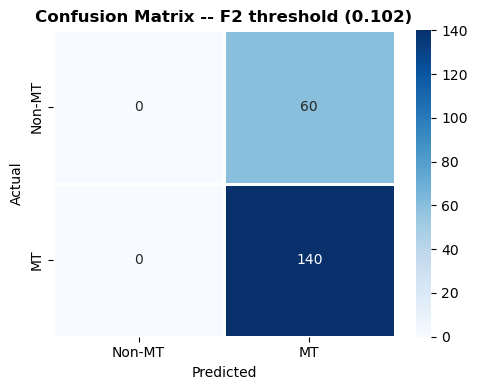

Results at Spec>=0.75 threshold (0.4666):
  Threshold      : 0.4666
  PR-AUC         : 0.921
  ROC-AUC        : 0.83
  Recall         : 0.757
  Specificity    : 0.783
  Precision      : 0.891
  F1             : 0.819
  F2             : 0.781
  Bal-Accuracy   : 0.77
  Brier          : 0.166

Classification report (Spec-threshold = 0.4666):
              precision    recall  f1-score   support

      Non-MT       0.58      0.78      0.67        60
          MT       0.89      0.76      0.82       140

    accuracy                           0.77       200
   macro avg       0.74      0.77      0.74       200
weighted avg       0.80      0.77      0.77       200



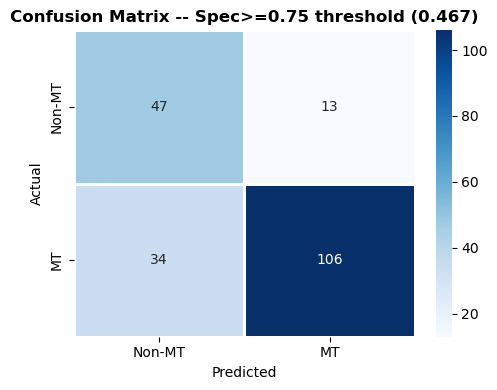

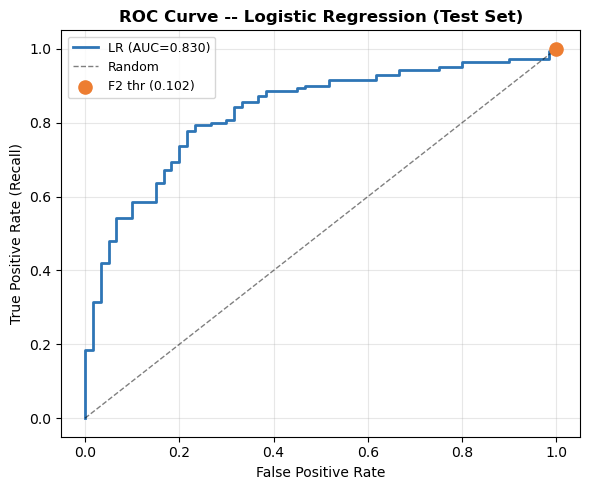

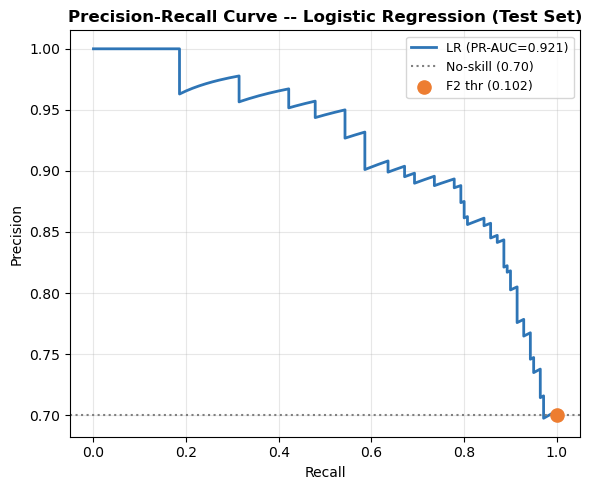

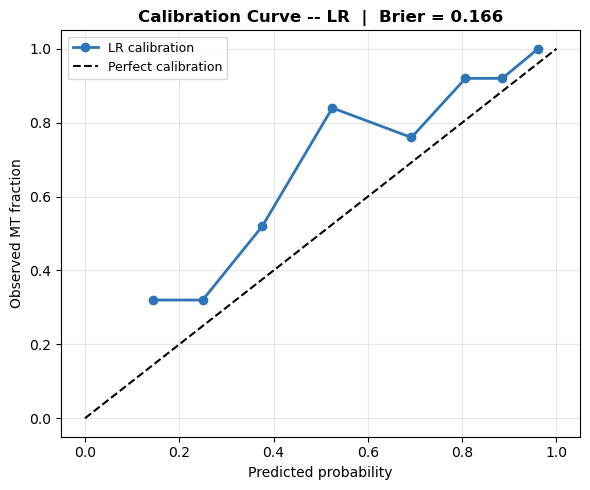

In [23]:
# Fit on full training set; predict once on test set
best_pipeline.fit(X_train[FEATURES], y_train)
test_probs = best_pipeline.predict_proba(X_test[FEATURES])[:, 1]

# --- F2-threshold results
m_f2, cm_f2 = compute_metrics(y_test, test_probs, thr_f2, 'LR (F2-threshold)')
print(f'Results at F2-threshold ({thr_f2:.4f}):')
for k, v in m_f2.items():
    if k != 'Model':
        print(f'  {k:<15}: {v}')
print(f'\nClassification report (F2-threshold = {thr_f2:.4f}):')
print(classification_report(y_test, (test_probs>=thr_f2).astype(int),
                            target_names=['Non-MT','MT'], zero_division=0))
plot_confusion_matrix(cm_f2,
    f'Confusion Matrix -- F2 threshold ({thr_f2:.3f})',
    OUTPUT_BASE, '06_confusion_matrix_f2.png')

# --- Spec-threshold results
m_spec, cm_spec = {}, None
if thr_spec is not None:
    m_spec, cm_spec = compute_metrics(y_test, test_probs, thr_spec,
                                      f'LR (Spec>=0.75 threshold)')
    print(f'Results at Spec>=0.75 threshold ({thr_spec:.4f}):')
    for k, v in m_spec.items():
        if k != 'Model':
            print(f'  {k:<15}: {v}')
    print(f'\nClassification report (Spec-threshold = {thr_spec:.4f}):')
    print(classification_report(y_test, (test_probs>=thr_spec).astype(int),
                                target_names=['Non-MT','MT'], zero_division=0))
    plot_confusion_matrix(cm_spec,
        f'Confusion Matrix -- Spec>=0.75 threshold ({thr_spec:.3f})',
        OUTPUT_BASE, '07_confusion_matrix_spec.png')

# --- Curves
plot_roc(test_probs, y_test, thr_f2, OUTPUT_BASE)
plot_pr(test_probs, y_test, thr_f2, OUTPUT_BASE)
plot_calibration(test_probs, y_test, m_f2['Brier'], OUTPUT_BASE)

---
## 12. Feature Interpretation

Two complementary views:

| Method | What it shows |
|---|---|
| **LR coefficients** | Direction and magnitude of each feature's linear contribution (standardized scale -- magnitudes are directly comparable) |
| **Permutation importance** | How much PR-AUC drops when each feature's values are shuffled on the **test set** |

### 12.1 Logistic Regression Coefficients

,Feature,Coefficient,Abs_Coefficient,Rank
0,Arterial_Base_Excess,-1.6762,1.6762,1
1,Lactate_mmol_L,1.5903,1.5903,2
2,Shock_Index,-0.8444,0.8444,3
3,Injury_Type_Coded,0.5515,0.5515,4
4,Age,-0.1203,0.1203,5
5,Sex_Coded,0.0307,0.0307,6
6,Heart_Rate_BPM,-0.0274,0.0274,7
7,Systolic_BP_mmHg,-0.0082,0.0082,8
8,Respiratory_Rate_BPM,0.0048,0.0048,9


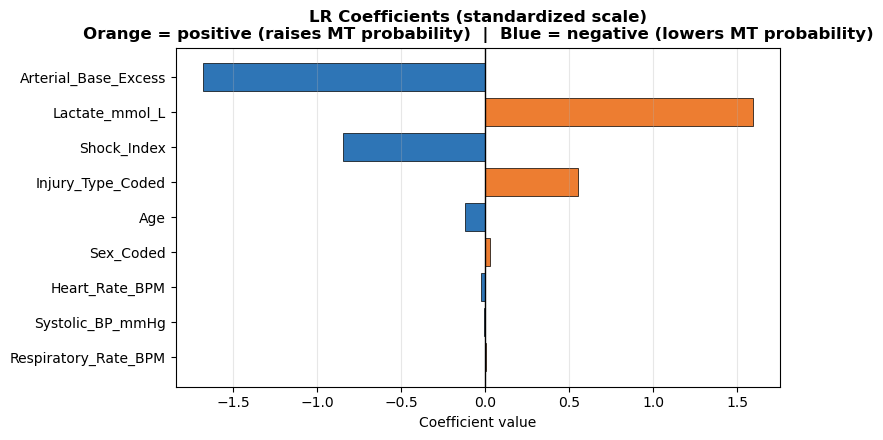

In [24]:
coef_df = pd.DataFrame({
    'Feature':         FEATURES,
    'Coefficient':     best_pipeline.named_steps['lr'].coef_[0].round(4),
    'Abs_Coefficient': np.abs(best_pipeline.named_steps['lr'].coef_[0]).round(4),
}).sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)
coef_df['Rank'] = range(1, len(coef_df)+1)

display(coef_df)

colors = ['#ED7D31' if v > 0 else '#2E75B6' for v in coef_df['Coefficient']]
fig, ax = plt.subplots(figsize=(8, max(4, len(coef_df)*0.5)))
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1],
        color=colors[::-1], edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', lw=1)
ax.set_title('LR Coefficients (standardized scale)\n'
             'Orange = positive (raises MT probability)  |  '
             'Blue = negative (lowers MT probability)',
             fontweight='bold')
ax.set_xlabel('Coefficient value')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'figures/11_coefficients.png', dpi=150)
plt.show()

### 12.2 Permutation Importance (Test Set)

,Feature,Mean_Decrease_PRAUC,Std
0,Lactate_mmol_L,0.1486,0.0158
1,Arterial_Base_Excess,0.1381,0.0241
2,Shock_Index,0.0389,0.0065
3,Injury_Type_Coded,0.0079,0.0066
4,Heart_Rate_BPM,0.0004,0.0004
5,Systolic_BP_mmHg,0.0002,0.0001
6,Respiratory_Rate_BPM,0.0001,0.0001
7,Sex_Coded,-0.0003,0.0004
8,Age,-0.0006,0.0014


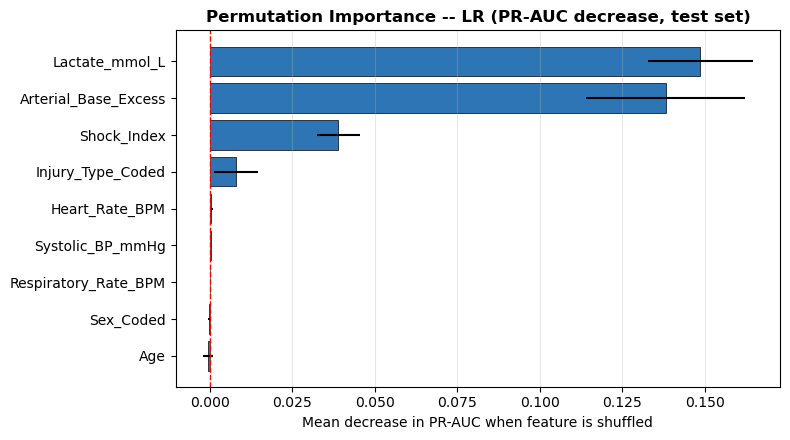

In [25]:
perm_result = sk_perm_importance(
    best_pipeline, X_test[FEATURES], y_test,
    scoring='average_precision',
    n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1,
)
perm_df = pd.DataFrame({
    'Feature':             FEATURES,
    'Mean_Decrease_PRAUC': perm_result.importances_mean.round(4),
    'Std':                 perm_result.importances_std.round(4),
}).sort_values('Mean_Decrease_PRAUC', ascending=False).reset_index(drop=True)

display(perm_df)

fig, ax = plt.subplots(figsize=(8, max(4, len(perm_df)*0.5)))
ax.barh(perm_df['Feature'][::-1], perm_df['Mean_Decrease_PRAUC'][::-1],
        xerr=perm_df['Std'][::-1],
        color='#2E75B6', edgecolor='black', linewidth=0.5)
ax.axvline(0, color='red', ls='--', lw=1)
ax.set_title('Permutation Importance -- LR (PR-AUC decrease, test set)',
             fontweight='bold')
ax.set_xlabel('Mean decrease in PR-AUC when feature is shuffled')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'figures/12_permutation_importance.png', dpi=150)
plt.show()

---
## 13. Save Artifacts

All results are saved to `outputs/logistic_regression/`:

| File | Content |
|---|---|
| `metrics.csv` | Test metrics for both threshold variants |
| `model_coefficients.csv` | Standardized LR coefficients |
| `best_hyperparameters.json` | Best params, CV PR-AUC, features, thresholds |
| `final_report.txt` | Full written report with placeholder teammate comparison table and iteration ideas |

In [26]:
# --- metrics.csv
metrics_rows = []
m_f2_save = dict(m_f2); m_f2_save['CV_PR-AUC'] = round(best_cv_prauc, 3)
metrics_rows.append(m_f2_save)
if m_spec:
    m_sp_save = dict(m_spec); m_sp_save['CV_PR-AUC'] = round(best_cv_prauc, 3)
    metrics_rows.append(m_sp_save)
pd.DataFrame(metrics_rows).to_csv(OUTPUT_BASE / 'metrics.csv', index=False)
print('Saved: metrics.csv')

# --- model_coefficients.csv
coef_df.to_csv(OUTPUT_BASE / 'model_coefficients.csv', index=False)
print('Saved: model_coefficients.csv')

# --- best_hyperparameters.json
hp_info = {
    'features':    FEATURES,
    'best_params': best_params,
    'cv_prauc':    round(best_cv_prauc, 3),
    'thr_f2':      round(thr_f2, 4),
    'thr_spec':    round(thr_spec, 4) if thr_spec is not None else None,
}
with open(OUTPUT_BASE / 'best_hyperparameters.json', 'w') as f:
    json.dump(hp_info, f, indent=2, default=str)
print('Saved: best_hyperparameters.json')

Saved: metrics.csv
Saved: model_coefficients.csv
Saved: best_hyperparameters.json


In [27]:
# --- final_report.txt
W = 72

def bar(title):
    return f'{"="*W}\n{title.upper()}\n{"="*W}\n'

preproc_text = (
    f'Clipping (clinical constants -- not data-derived, not leakage):\n'
    f'  Systolic_BP_mmHg -> [40, 250] mmHg\n'
    f'  Heart_Rate_BPM   -> [20, 220] bpm\n'
    f'  Shock_Index recomputed from clipped HR / SBP after clipping.\n\n'
    f'Encoding (deterministic, no statistics learned):\n'
    f'  Sex -> Sex_Coded           (Female=1, Male=0)\n'
    f'  Injury_Type -> Injury_Type_Coded  (Penetrating=1, Blunt=0)\n'
)

feat_text = (
    f'Single feature set ({len(FEATURES)} features):\n'
    + '\n'.join(f'  {f}' for f in FEATURES) + '\n\n'
    + 'Shock_Index is included as a regular clinical feature.\n'
    + 'Regularization and cross-validation determine its contribution.\n\n'
    + 'Correlations: see figures/05_correlation_heatmap.png'
)

model_text = (
    f'Baseline LR CV PR-AUC : {baseline["cv_prauc"]:.4f}\n'
    f'Best LR CV PR-AUC     : {best_cv_prauc:.4f}\n'
    f'Improvement           : {best_cv_prauc - baseline["cv_prauc"]:+.4f}\n\n'
    f'Best hyperparameters  : {best_params}\n'
    f'Features              : {FEATURES}\n\n'
    f'Thresholds (selected on OOF, training data only):\n'
    f'  F2-optimal  : {thr_f2:.4f}\n'
    f'  Spec>=0.75  : {thr_spec}\n\n'
    f'Test set results (F2-threshold):\n'
    + '\n'.join(f'  {k:<15}: {v}' for k, v in m_f2.items() if k != 'Model')
)

diff_text = (
    f'Class imbalance : 3:1 -- compensated with class_weight="balanced"\n'
    f'Calibration     : see figures/10_calibration_curve.png '
    f'(Brier={m_f2["Brier"]})\n'
    f'Overall         : moderately difficult binary classification task.\n'
    f'                  Recall and PR-AUC are the primary metrics.'
)

col_w   = [24, 10, 8, 9, 8, 12, 6, 7, 10]
hdrs    = ['Model','CV PR-AUC','PR-AUC','ROC-AUC',
           'Recall','Specificity','F2','Brier','Threshold']
sep     = '  '.join('-'*w for w in col_w)
hdr_row = '  '.join(h.ljust(w) for h, w in zip(hdrs, col_w))
lr_row  = [
    'Logistic Regression',
    str(round(best_cv_prauc,3)),
    str(m_f2['PR-AUC']), str(m_f2['ROC-AUC']), str(m_f2['Recall']),
    str(m_f2['Specificity']), str(m_f2['F2']), str(m_f2['Brier']),
    str(round(thr_f2,3)),
]
table = '\n'.join([
    'Model selection criterion: CV PR-AUC on training set only.',
    'Complete this table when teammates submit their models.\n',
    hdr_row, sep,
    '  '.join(v.ljust(w) for v, w in zip(lr_row, col_w)),
    '  '.join(['Random Forest'.ljust(col_w[0])] + ['[TBD]'.ljust(w) for w in col_w[1:]]),
    '  '.join(['XGBoost'.ljust(col_w[0])]       + ['[TBD]'.ljust(w) for w in col_w[1:]]),
])

iter_ideas = (
    '1. Log-transform for skewed features\n'
    '   Lactate_mmol_L and Arterial_Base_Excess show right skew.\n'
    '   Log-transform before scaling may improve linear separability.\n\n'
    '2. Probability calibration\n'
    '   If calibration curve deviates from the diagonal, apply\n'
    '   CalibratedClassifierCV(method="sigmoid") on top of best pipeline.\n\n'
    '3. Explicit class weight tuning\n'
    '   Replace class_weight="balanced" with manual ratios\n'
    '   (e.g., {0:1, 1:3}) via the existing OOF CV framework.\n\n'
    '4. Threshold clinical alignment\n'
    '   If neither threshold achieves Recall >= 0.90, consult\n'
    '   the clinical team to set an explicit minimum recall floor.'
)

sections = {
    '1. EDA Summary':                           'See figures/ for full EDA output.',
    '2. Preprocessing Decisions':               preproc_text,
    '3. Feature Set':                           feat_text,
    '4. Model Selection':                       model_text,
    '5. Estimated Task Difficulty':             diff_text,
    '6. Future Comparison with Teammate Models': table,
    '7. Iteration Ideas':                       iter_ideas,
}

report_lines = [bar('Logistic Regression Workflow -- Final Report')]
report_lines.append(
    f'Generated : {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}\n'
    f'Seed      : {RANDOM_SEED}   |   Test size: {TEST_SIZE}\n'
    f'Data file : {DATA_PATH}\n'
)
for title, content in sections.items():
    report_lines.append(bar(title))
    report_lines.append(content + '\n')

(OUTPUT_BASE / 'final_report.txt').write_text('\n'.join(report_lines), encoding='utf-8')
print('Saved: final_report.txt')
print(f'\nAll outputs saved to: {OUTPUT_BASE.resolve()}')

Saved: final_report.txt

All outputs saved to: C:\Users\aysha\Predict-Massive-Transfusion-in-Trauma-PatieUsing-Early-Clinical-Parameters\scripts\outputs\logistic_regression




**Outputs saved to `outputs/logistic_regression/`:**

```
figures/
  01_class_distribution.png
  02_missing_values.png
  03_feature_histograms.png
  04_violin_by_target.png
  05_correlation_heatmap.png
  06_confusion_matrix_f2.png
  07_confusion_matrix_spec.png
  08_roc_curve.png
  09_pr_curve.png
  10_calibration_curve.png
  11_coefficients.png
  12_permutation_importance.png
metrics.csv
model_coefficients.csv
best_hyperparameters.json
final_report.txt
```

Teammate models (Random Forest, XGBoost) fill the `[TBD]` rows in `final_report.txt`.